In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# we will load files individually because they are distinct asset classes
df_mebl = pd.read_csv('raw_data/MEBL.csv', parse_dates=['Date'], index_col='Date', thousands=',')
df_gold = pd.read_csv('raw_data/XAU_USD.csv', parse_dates=['Date'], index_col='Date', thousands=',')
df_btc = pd.read_csv('raw_data/BTC_USD.csv', parse_dates=['Date'], index_col='Date', thousands=',')
df_usd = pd.read_csv('raw_data/USD_PKR.csv', parse_dates=['Date'], index_col='Date', thousands=',')

# SORT the dates immediately (Investing.com usually gives newest first, we want oldest first)df_mebl.sort_index(inplace=True)
df_gold.sort_index(inplace=True)
df_btc.sort_index(inplace=True)
df_usd.sort_index(inplace=True)

print(f"MEBL Range: {df_mebl.index.min()} to {df_mebl.index.max()}")

MEBL Range: 2020-01-01 00:00:00 to 2026-01-27 00:00:00


In [3]:
# Step 1: Combine the data
df_combined = pd.concat([df_mebl['Price'], df_usd['Price']], axis=1)
df_combined

,Price,Price
Date,,
2020-01-01,69.23,154.470
2020-01-02,70.12,154.600
2020-01-03,69.40,154.450
2020-01-04,NaN,154.875
2020-01-06,68.45,154.470
...,...,...
2026-01-23,486.39,279.800
2026-01-24,NaN,279.800
2026-01-25,NaN,279.800


In [4]:
# Step 2: Rename columns 
# as both are named Price right now
df_combined.columns = ["MEBL_PKR", 'USD_PKR_Rate']
df_combined

,MEBL_PKR,USD_PKR_Rate
Date,,
2020-01-01,69.23,154.470
2020-01-02,70.12,154.600
2020-01-03,69.40,154.450
2020-01-04,NaN,154.875
2020-01-06,68.45,154.470
...,...,...
2026-01-23,486.39,279.800
2026-01-24,NaN,279.800
2026-01-25,NaN,279.800


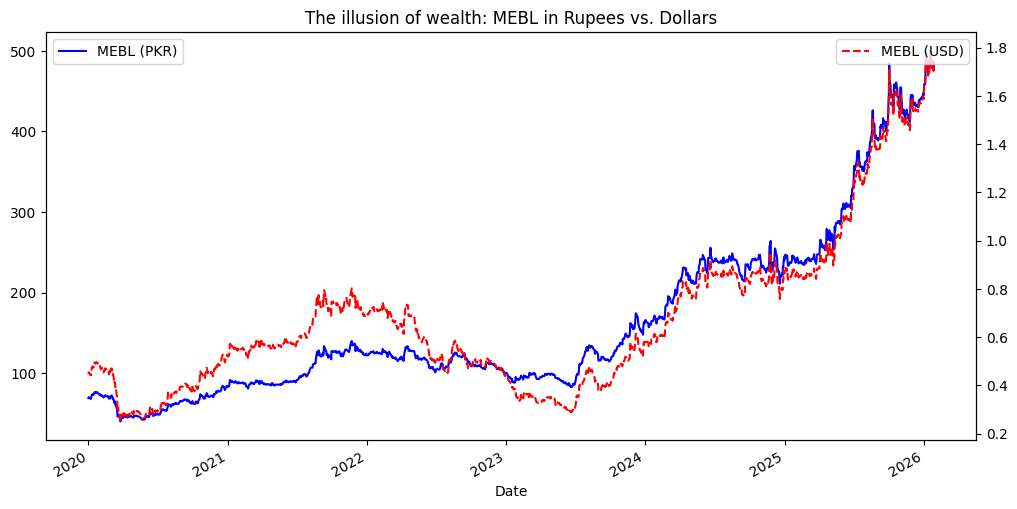

In [5]:
# Step 3: Cleaning Weekends
# MEBL doesn't trade on weekends. USD/PKR might.
# We use Forward Fill (ffill) to make sure we have values for every day.

df_combined.ffill(inplace = True)
df_combined.dropna(inplace=True) # Drop any days that are still empty
# df_combined

# Step 4: The conversion
# We will convert MEBL from pkr to usd
df_combined['MEBL_USD'] = df_combined['MEBL_PKR'] / df_combined ['USD_PKR_Rate']
# df_combined

# Step 5: Now we plot it!
plt.figure(figsize=(12, 6))
ax1 = df_combined['MEBL_PKR'].plot(color = 'blue', label = 'MEBL (PKR)')
plt.legend(loc = 'upper left')

ax2 =  ax1.twinx() # this creates  a second Y-axis sharing same X-axis
df_combined['MEBL_USD'].plot(color = 'red', linestyle = '--', label = 'MEBL (USD)', ax=ax2)
plt.legend(loc = 'upper right')

plt.title('The illusion of wealth: MEBL in Rupees vs. Dollars')
# plt.style.use('light_background')
plt.show()

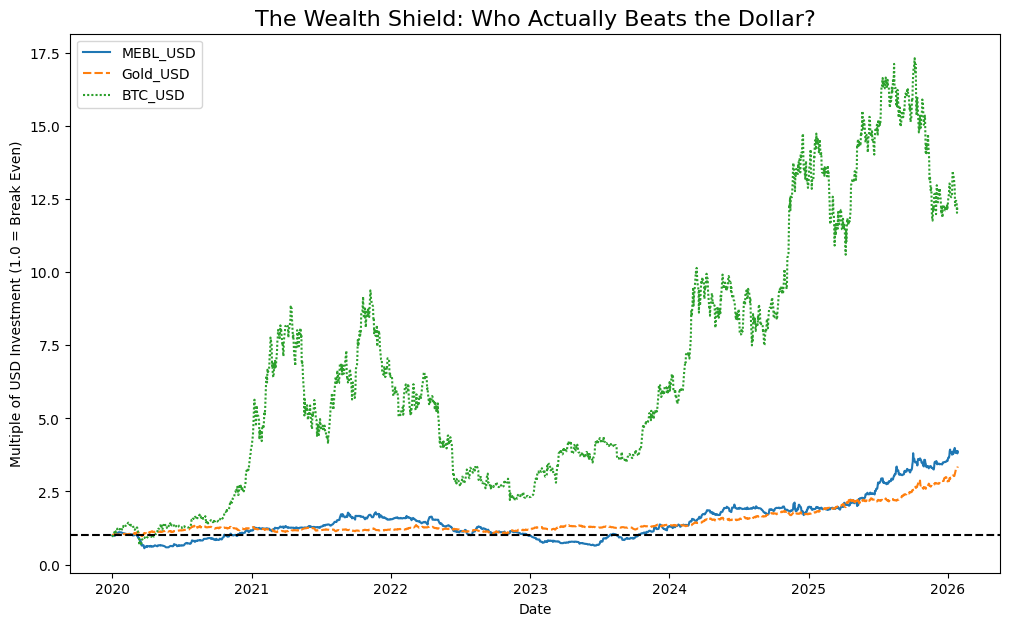

In [6]:
# Step 1: Prepare competitors
# lets add MEBL first
race_df = pd.DataFrame()
race_df['MEBL_USD'] = df_combined['MEBL_USD']

# Now add Gold 
# We have to align dates as well so we use reindex
race_df['Gold_USD'] = df_gold['Price'].reindex(race_df.index, method='ffill')

# Add bitcoin
race_df['BTC_USD'] = df_btc['Price'].reindex(race_df.index, method='ffill')


# Step 2: Now we need everyone to start with 1.0 to normalize
# This forces everyone to start at 1.0
race_df_normalized = race_df / race_df.iloc[0]

# Step 3: Visualize
plt.figure(figsize=(12, 7))
sns.lineplot(data = race_df_normalized)

plt.title('The Wealth Shield: Who Actually Beats the Dollar?', fontsize=16)
plt.ylabel('Multiple of USD Investment (1.0 = Break Even)')
plt.axhline(1.0, color = 'black', linestyle = '--')
plt.show()

In [7]:
# first we will create helper function for the chart
def plot_illusion(asset_name, df_asset, df_rate):
    # 1. Merge asset (USD) with rate (USD/PKR)
    df_merged = pd.concat([df_asset['Price'], df_rate['Price']], axis=1)
    df_merged.columns = [f"{asset_name}_USD", "USD_PKR_Rate"]
    
    # 2. Fill the gaps
    df_merged.ffill(inplace = True)
    df_merged.dropna(inplace = True)
    
    # 3. Create illusion column (Calc price in rupees)
    # Formula: Asset Price ($) * Dollar Rate (Rs)
    df_merged[f"{asset_name}_PKR"] = df_merged[f"{asset_name}_USD"] * df_merged['USD_PKR_Rate']
    
    # 4. Plot
    plt.figure(figsize = (12, 6))
    
    # Left Axis: The Rupee Price (What you see on the News)
    ax1 = df_merged[f'{asset_name}_PKR'].plot(color = 'blue', label = f"{asset_name} (PKR) - The Illusion")
    plt.ylabel(f"Price in PKR (The News Price)")
    plt.legend(loc='upper left')
    
    # Right Axis: The Dollar Price (The Real Value)
    ax2 = ax1.twinx()
    df_merged[f'{asset_name}_USD'].plot(color = 'red', linestyle = '--', label = f'{asset_name} (USD) - The Truth', ax = ax2)
    plt.ylabel("Price in USD (Real Value)")
    plt.legend(loc = 'lower right')
    
    
    plt.title(f"The illusion of Wealth: {asset_name} (Rupees vs Dollars)")
    plt.show()

--- Generating Gold Chart ---


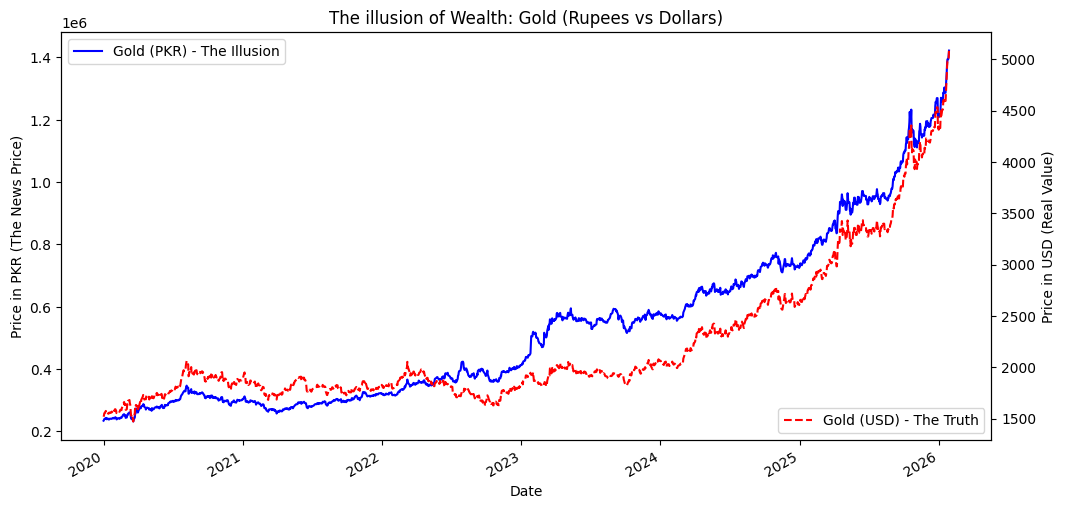

In [8]:
# --- Run for Gold ---
print("--- Generating Gold Chart ---")
plot_illusion('Gold', df_gold, df_usd)

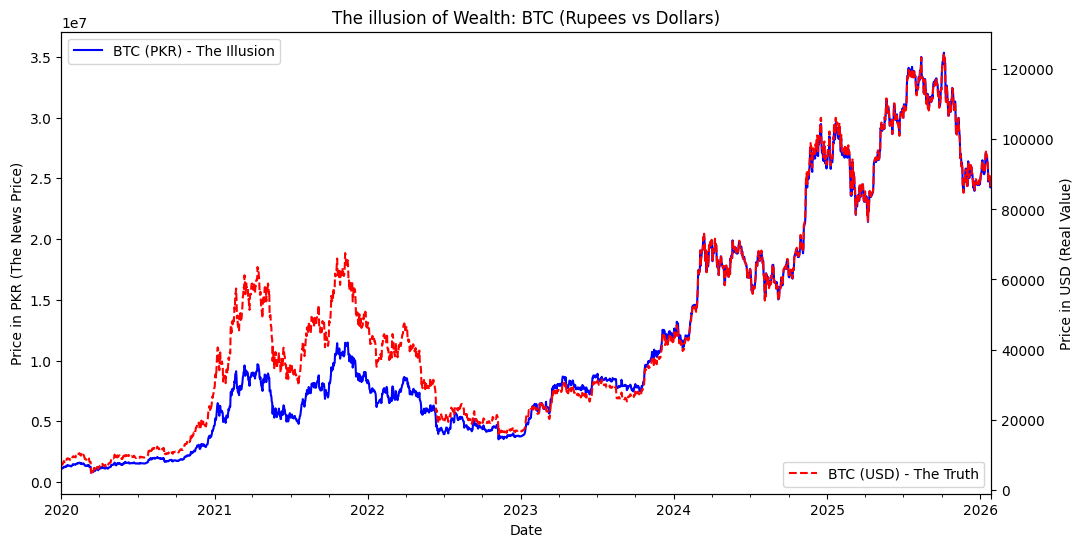

In [9]:
# for btc
plot_illusion('BTC', df_btc, df_usd)

In [10]:
race_df_normalized

,MEBL_USD,Gold_USD,BTC_USD
Date,,,
2020-01-01,1.000000,1.000000,1.000000
2020-01-02,1.012004,1.007672,0.967666
2020-01-03,1.002585,1.022639,1.019903
2020-01-04,0.999834,1.022639,1.024584
2020-01-06,0.988733,1.032070,1.077683
...,...,...,...
2026-01-23,3.878705,3.284064,12.442096
2026-01-24,3.878705,3.284064,12.396858
2026-01-25,3.878705,3.284064,12.033945


In [11]:
# first we define our weights
weight_gold = 0.50
weight_mebl = 0.30
weight_btc = 0.20

# --- Step 2: The "Weighted Sum" Math ---
# We use the normalized data (where everyone starts at 1.0)
# This simulates "Buying and Holding" starting with $1.00 split across assets
race_df_normalized["My_Portfolio"] = (
    (race_df_normalized['Gold_USD'] * weight_gold) + 
    (race_df_normalized['MEBL_USD'] * weight_mebl) +
    (race_df_normalized['BTC_USD'] * weight_btc)
)
race_df_normalized

,MEBL_USD,Gold_USD,BTC_USD,My_Portfolio
Date,,,,
2020-01-01,1.000000,1.000000,1.000000,1.000000
2020-01-02,1.012004,1.007672,0.967666,1.000970
2020-01-03,1.002585,1.022639,1.019903,1.016076
2020-01-04,0.999834,1.022639,1.024584,1.016186
2020-01-06,0.988733,1.032070,1.077683,1.028192
...,...,...,...,...
2026-01-23,3.878705,3.284064,12.442096,5.294063
2026-01-24,3.878705,3.284064,12.396858,5.285015
2026-01-25,3.878705,3.284064,12.033945,5.212432


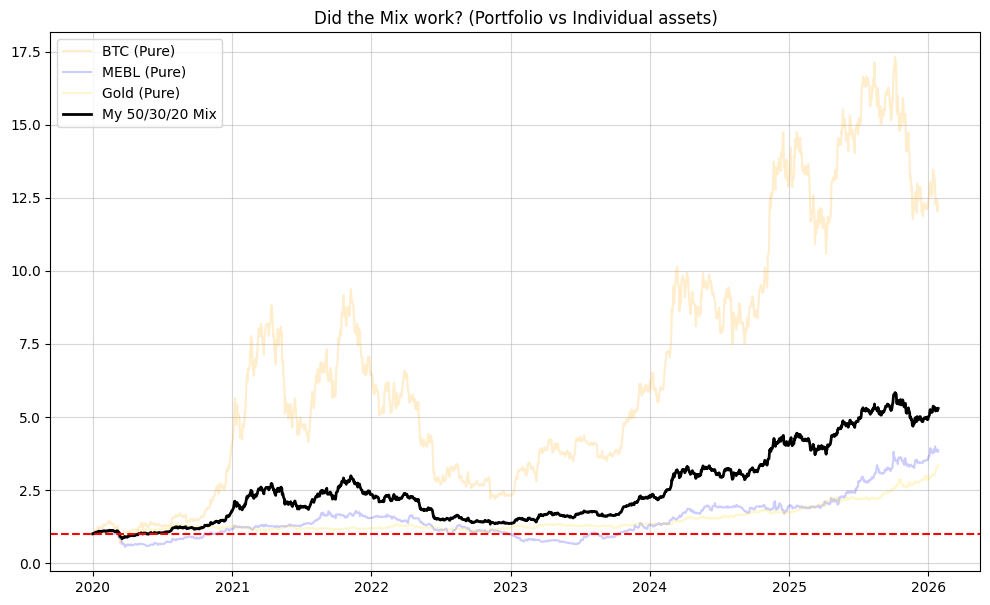

In [12]:
# 3. Plot
plt.figure(figsize=(12, 7))

# Plot the Ingredients (Faintly) to show context
plt.plot(race_df_normalized.index, race_df_normalized['BTC_USD'], color = 'orange', alpha = 0.2, label = 'BTC (Pure)')
plt.plot(race_df_normalized.index, race_df_normalized['MEBL_USD'], color = 'blue', alpha = 0.2, label = 'MEBL (Pure)')
plt.plot(race_df_normalized.index, race_df_normalized['Gold_USD'], color = 'gold', alpha = 0.2, label = 'Gold (Pure)')

# Plot YOUR Portfolio (Thick Black Line)
plt.plot(race_df_normalized.index, race_df_normalized['My_Portfolio'], color = 'black', linewidth = 2, label = 'My 50/30/20 Mix')

plt.title("Did the Mix work? (Portfolio vs Individual assets)")
plt.axhline(1.0, color = 'red', linestyle = '--') # The inflation line
plt.legend()
plt.grid(True, alpha = 0.5)
plt.show()

In [13]:
# 4. The Final Verdict number
final_value = race_df_normalized['My_Portfolio'].iloc[-1]
print("If you invested $1000 in 2020...")
print(f"You would have: ${final_value * 1000:.2f} today.")
print(f"Portfolio Multiplier: {final_value:.2f}x")

If you invested $1000 in 2020...
You would have: $5290.52 today.
Portfolio Multiplier: 5.29x


In [14]:
# 1. Setup
# We need Log Returns for statistical accuracy in simulations
log_returns = np.log(race_df / race_df.shift(1))
num_portfolios = 5000 # we will generate 5000 random mixes
all_weights = np.zeros((num_portfolios, 3)) # To store the weights (Gold, MEBL, BTC)
ret_arr = np.zeros(num_portfolios)
vol_arr = np.zeros(num_portfolios)
sharpe_arr = np.zeros(num_portfolios)

print("--- AI Simulation Started: Testing 5,000 Strategies ---")

# 2. The loop
for ind in range(num_portfolios):
    weights = np.array(np.random.random(3))
    
    # Normalize them so they add up to 1.0 (100%)
    weights = weights / np.sum(weights)
    
    all_weights[ind, :] = weights
    
    # calc expected return (annualized) assuming 252 trading days
    # This is a statistical projection based on history
    ret_arr[ind] = np.sum((log_returns.mean() * weights) * 252)
    
    # calc volatility (risk)
    vol_arr[ind] = np.sqrt(np.dot(weights, np.dot(log_returns.cov() * 252, weights)))
    
    # calc sharpe ratio ( return / risk)
    sharpe_arr[ind] = ret_arr[ind] / vol_arr[ind]
    
# race_df.columns # We just checked the order it was MEBL, XAU then BTC so we good
    
# 3. Find the winner
max_sharpe_idx = sharpe_arr.argmax()
best_weights = all_weights[max_sharpe_idx, :]

print("\n--- AI Recommendation Found ---")
print(f"Best Sharpe Ratio: {sharpe_arr[max_sharpe_idx]:.2f}")
print("Optimal Allocation: ")
print(f"   MEBL: {best_weights[0] * 100:.1f}%")
print(f"   Gold: {best_weights[1] * 100:.1f}%")
print(f"   BTC: {best_weights[2] * 100:.1f}%")
    

--- AI Simulation Started: Testing 5,000 Strategies ---

--- AI Recommendation Found ---
Best Sharpe Ratio: 1.37
Optimal Allocation: 
   MEBL: 18.8%
   Gold: 73.3%
   BTC: 7.8%


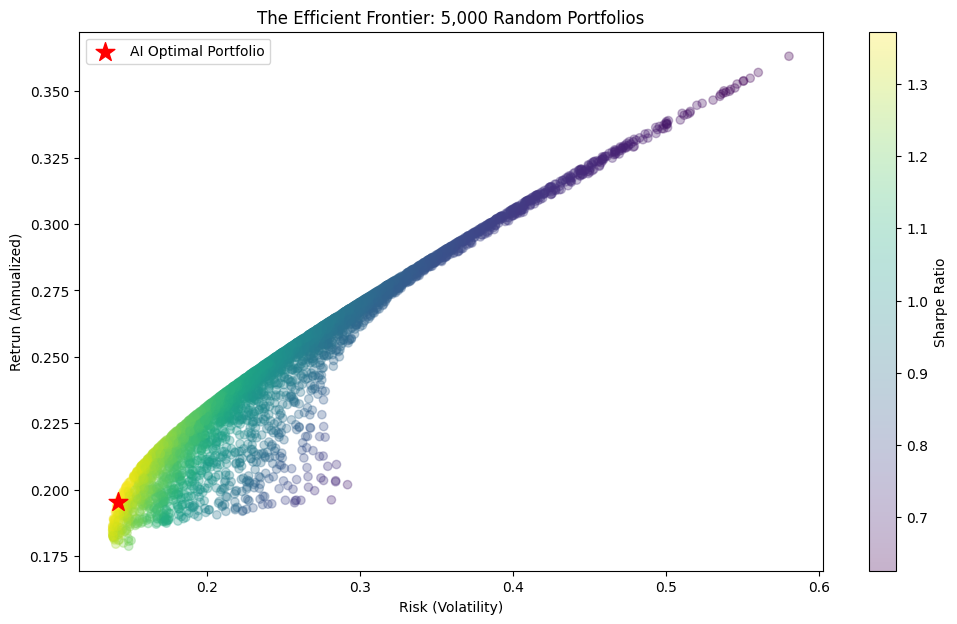

In [15]:
# step 4: Visualizing the efficient frontier
plt.figure(figsize=(12, 7))

plt.scatter(vol_arr, ret_arr, c = sharpe_arr, cmap='viridis', alpha = 0.3)
plt.colorbar(label = 'Sharpe Ratio')

# Mark the Winner with a Red Star
plt.scatter(vol_arr[max_sharpe_idx], ret_arr[max_sharpe_idx], c = 'red', s=200, marker='*', label = 'AI Optimal Portfolio')

plt.title("The Efficient Frontier: 5,000 Random Portfolios")
plt.xlabel("Risk (Volatility)")
plt.ylabel("Retrun (Annualized)")
plt.legend()
plt.show()

In [16]:
#Step 1: Calc the secret numbers
# We use .corr() (Correlation) not .cov() (Covariance)
# Covariance is for math (unbounded numbers). Correlation is for humans (-1 to +1).
corr_matrix = log_returns.corr()
corr_matrix

,MEBL_USD,Gold_USD,BTC_USD
MEBL_USD,1.000000,0.054173,0.069659
Gold_USD,0.054173,1.000000,0.124956
BTC_USD,0.069659,0.124956,1.000000


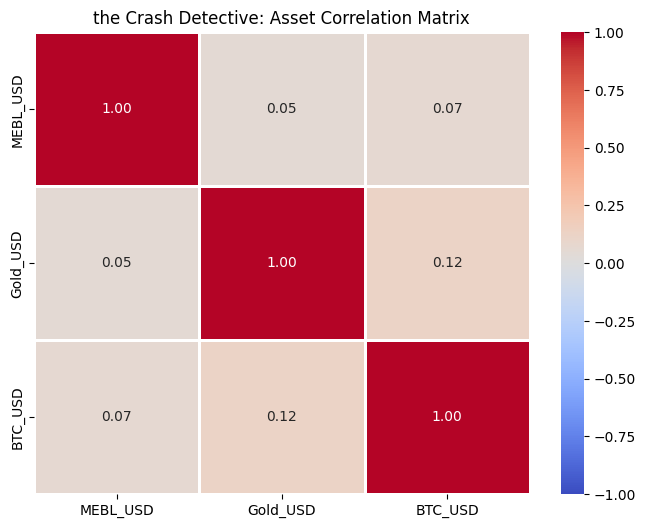

In [17]:
# Step 2: Heatmap
plt.figure(figsize = (8, 6))

# sns.heatmap arguments:
# annot=True: Write the actual numbers inside the boxes
# cmap='coolwarm': Red = Positive (Hot/Danger), Blue = Negative (Cool/Safe)
# vmin=-1, vmax=1: Force the scale to be exactly -1 to +1 
# linewidths=1: Add white lines between boxes for style
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=1, fmt = '.2f')

plt.title("the Crash Detective: Asset Correlation Matrix")
plt.show()

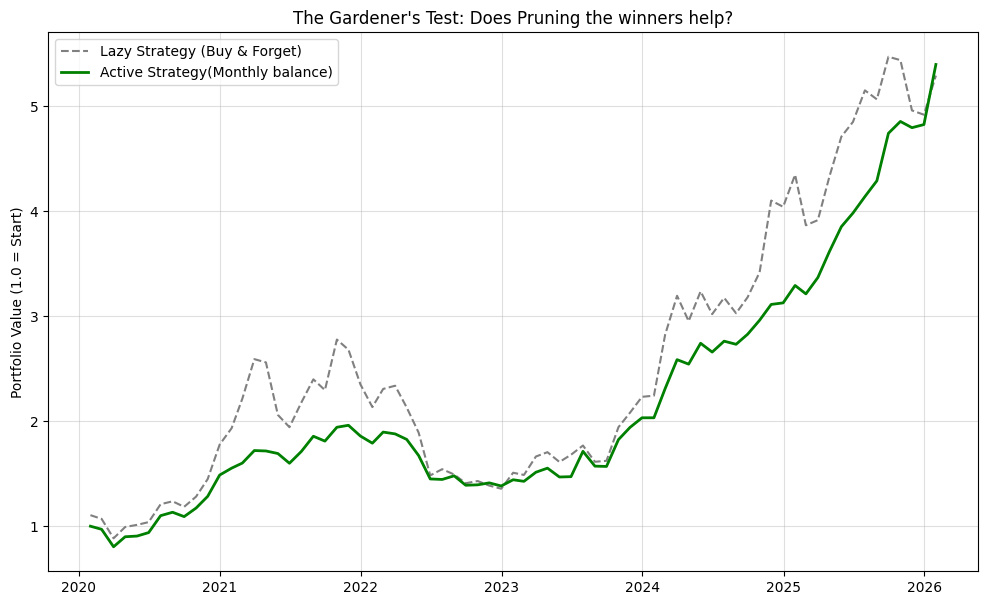

In [18]:
# Step 1: Setup the "Active" engine!
# We need to loop through time, so we convert data to 'Monthly' to make it faster/cleaner
# .resample('M').last() takes the last price of every month
monthly_df = race_df_normalized.resample('ME').last()

# Now define our target weights (the 'ideal' mix)
target_weights = np.array([0.50, 0.30, 0.20]) # Gold, MEBL, BTC

# Storage for simulation
active_portfolio_val = [1.0] # Start at 1.0 (normalized)

# 2. Rebalancing Loop
for i in range(1, len(monthly_df)):
    
    # A. Calculate Return for this specific month for EACH asset
    # (Price This Month / Price Last Month)
    cols = ['Gold_USD', 'MEBL_USD', 'BTC_USD']
    monthly_return = monthly_df[cols].iloc[i] / monthly_df[cols].iloc[i-1]
    
    # B. Apply the return for this specific month for EACH asset
    # If we just held the assets, they grew by 'monthly_return'
    # But wait! Last month we 'reset' our money to be 50/30/20 split.
    # So we multiply the Weights * Returns
    portfolio_growth = np.sum(target_weights * monthly_return)
    
    # C. Update total wealth
    # New wealth = Old wealth * Growth
    current_wealth = active_portfolio_val[-1] * portfolio_growth
    active_portfolio_val.append(current_wealth)
    
# 3. Comparison Plot
plt.figure(figsize=(12, 7))

# Plot the Lazy Strategy (From Ticket #5 - we just re-plot it)
# We limit it to the monthly timeframe so it matches
plt.plot(monthly_df.index, monthly_df['My_Portfolio'], color = 'gray', linestyle = '--', label = 'Lazy Strategy (Buy & Forget)')

# Plot the Active Strategy
plt.plot(monthly_df.index, active_portfolio_val, color = 'green', linewidth = 2, label = "Active Strategy(Monthly balance)")

plt.title("The Gardener's Test: Does Pruning the winners help?")
plt.ylabel("Portfolio Value (1.0 = Start)")
plt.legend()
plt.grid(True, alpha = 0.4)
plt.show()

In [19]:
# 4. Final Verdict
lazy_final = monthly_df['My_Portfolio'].iloc[-1]
active_final = active_portfolio_val[-1]

print(f"Lazy Strategy Final: {lazy_final:.2f}x")
print(f"Active Strategy Final: {active_final:.2f}x")

if active_final > lazy_final:
    print("Verdict: BEING ACTIVE WON! (Selling High/Buying Low worked)")
else:
    print("Verdict: LAZY WON! (You shouldn't have sold the winners)")

Lazy Strategy Final: 5.29x
Active Strategy Final: 5.40x
Verdict: BEING ACTIVE WON! (Selling High/Buying Low worked)


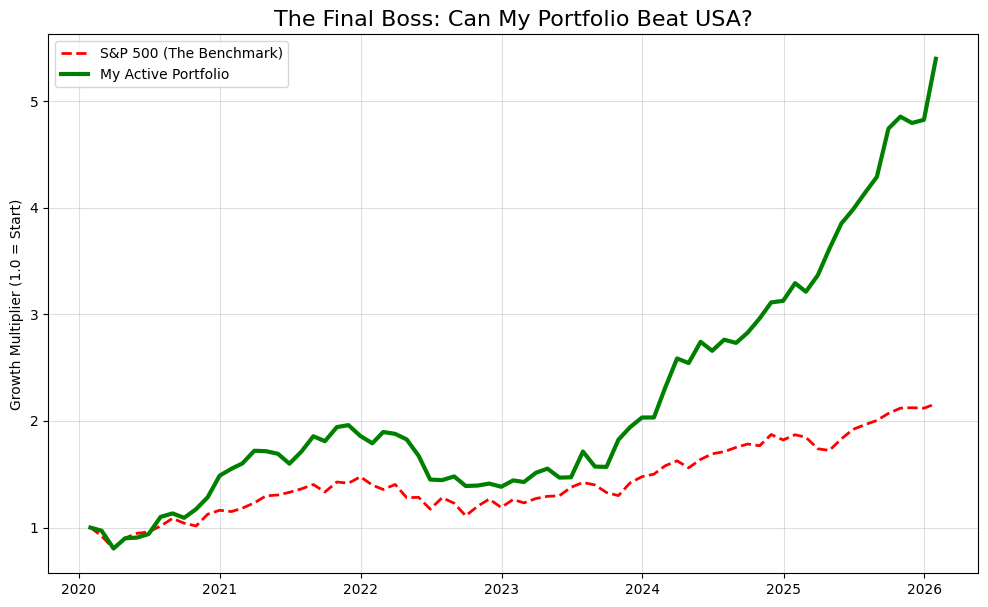

In [20]:
# 1. Summon it here
df_spy = pd.read_csv('raw_data/SPY_USD.csv', parse_dates=['Date'], index_col='Date', thousands=',')
df_spy.sort_index(inplace=True)
# df_spy

# 2. The equalizer (Normalization)
# We need to make SPY start at 1.0 on the SAME DAY our simulation started.
# We align it with our 'monthly_df' dates
spy_monthly = df_spy['Price'].reindex(monthly_df.index, method='ffill')

# Force start at 1.0
spy_normalized = spy_monthly / spy_monthly.iloc[0]

# Step 3: The Championship Ring
plt.figure(figsize=(12,7))

# Corner 1: The Lazy American (S&P 500)
plt.plot(spy_normalized.index, spy_normalized, color = 'red', linewidth = 2, linestyle = '--', label = "S&P 500 (The Benchmark)")

plt.plot(monthly_df.index, active_portfolio_val, color = 'green', linewidth = 3, label = "My Active Portfolio")

plt.title("The Final Boss: Can My Portfolio Beat USA?", fontsize = 16)
plt.ylabel("Growth Multiplier (1.0 = Start)")
plt.legend()
plt.grid(True, alpha = 0.4)
plt.show()

In [21]:
# Step 4: The Scoreboard
spy_final = spy_normalized.iloc[-1]
my_final = active_portfolio_val[-1]

print(f"S&P 500 Final: {spy_final:.2f}")
print(f"My Portfolio Final: {my_final:.2f}")

if my_final > spy_final:
    print("\nVICTORY! My Strategy won!")
else:
    print("\nDEFEAT. The Lazy American won. Next time, just buy SPY.")

S&P 500 Final: 2.16
My Portfolio Final: 5.40

VICTORY! My Strategy won!


In [22]:
# --- Step 1: Calculate Professional Metrics ---
def get_metrics(price_series, label):
    #1. Total returns
    total_ret = price_series.iloc[-1] / price_series.iloc[0] - 1
    
    # 2. CAGR (Compound Annual Growth Rate) - The "Yearly Average"
    days = (price_series.index[-1] - price_series.index[0]).days
    years = days / 365.25
    cagr = ((price_series.iloc[-1] / price_series.iloc[0]) ** (1/years)) - 1
    
    # 3. Max Drawdown (The "Scariest Moment")
    # We find the peak, then find how far we fell from that peak
    rolling_max = price_series.cummax()
    drawdown = (price_series - rolling_max) / rolling_max
    max_dd = drawdown.min()
    
    return total_ret, cagr, max_dd

# Get Stats for USA (SPY) and Pakistan (Your Portfolio)
# Note: Ensure these series are normalized (start at 1.0)
spy_stats = get_metrics(spy_normalized, "S&P 500")
my_stats = get_metrics(pd.Series(active_portfolio_val, index=monthly_df.index), 'My Portfolio')

In [23]:
# 2. Resume Printout
print("="*45)
print(f"    PROJECT WEALTH SHIELD: FINAL REPORT   ")
print("="*45)

print("\n BENCHMARK (S&P 500)")
print("-----------------------")
print(f"Total Return: {spy_stats[0] * 100:.2f}%")
print(f"Annual Growth: {spy_stats[1] * 100:.2f}% (CAGR)")
print(f"Worst Crash: {spy_stats[2] * 100:.2f}% (MAX Drawdown)")

print("\n MY STRATEGY (Active 50/30/20)")
print("-----------------------")
print(f"Total Return: {my_stats[0] * 100:.2f}%")
print(f"Annual Growth: {my_stats[1] * 100:.2f}% (CAGR)")
print(f"Worst Crash: {my_stats[2] * 100:.2f}% (MAX Drawdown)")

print("\n" + "=" * 45)
if my_stats[0] > spy_stats[0]:
    print(f"VERDICT: OUTPERFORMANCE DETECTED.")
    print(f"You beat the market by {my_stats[0] * 100 - spy_stats[0] * 100:.1f} percentage points")
else:
    print(f"VERDICT: UNDERPERFORMANCE.")
print("="*40)

    PROJECT WEALTH SHIELD: FINAL REPORT   

 BENCHMARK (S&P 500)
-----------------------
Total Return: 116.17%
Annual Growth: 13.71% (CAGR)
Worst Crash: -24.80% (MAX Drawdown)

 MY STRATEGY (Active 50/30/20)
-----------------------
Total Return: 439.65%
Annual Growth: 32.43% (CAGR)
Worst Crash: -29.47% (MAX Drawdown)

VERDICT: OUTPERFORMANCE DETECTED.
You beat the market by 323.5 percentage points
